In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv('/content/ITC.NS.csv')

print("Original Shape:", df.shape)
print("\nOriginal Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


Original Shape: (6890, 7)

Original Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First 5 rows:
         Date      Open      High       Low     Close  Adj Close      Volume
0  01-01-1996  5.550000  5.600000  5.533333  5.583333   3.323907    985500.0
1  02-01-1996  5.466666  5.566666  5.288888  5.372222   3.198226   7470000.0
2  03-01-1996  5.133333  5.254444  5.101111  5.200000   3.095698  15160500.0
3  04-01-1996  5.200000  5.332222  5.144444  5.297777   3.153908  12397500.0
4  05-01-1996  5.297777  5.277777  5.188888  5.202222   3.097020   5008500.0


In [11]:
if 'Date' not in df.columns:
    if df.index.name == 'Date':
        df = df.reset_index()
    else:
        df = df.reset_index()


df.columns = df.columns.astype(str).str.strip()

print("\nColumns after fixing Date:")
print(df.columns.tolist())


Columns after fixing Date:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [12]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])


df = df.sort_values('Date').reset_index(drop=True)

In [13]:
required_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

print("\nChecking required columns...")

for col in required_columns:
    if col not in df.columns:
        print("WARNING: Missing column ->", col)


Checking required columns...


In [14]:
print("\nMissing values BEFORE cleaning:")
print(df.isnull().sum())


available_price_columns = [col for col in required_columns if col in df.columns]

df[available_price_columns] = df[available_price_columns].ffill()


Missing values BEFORE cleaning:
Date         0
Open         5
High         5
Low          5
Close        5
Adj Close    5
Volume       5
dtype: int64


In [15]:

duplicate_dates = df['Date'].duplicated().sum()
print("\nDuplicate dates:", duplicate_dates)

df = df.drop_duplicates(subset='Date')



df.set_index('Date', inplace=True)


Duplicate dates: 0


In [16]:

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

print("\nFinal Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nData integrity check completed.")


Missing values AFTER cleaning:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Final Shape: (2718, 6)

Data Types:
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object

Data integrity check completed.


In [17]:

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS — CLOSING PRICE")
print("="*60)

desc = df['Close'].describe()
print(desc)

print(f"\nMean closing price: Rs {df['Close'].mean():.2f}")
print(f"Median closing price: Rs {df['Close'].median():.2f}")
print(f"Std deviation: Rs {df['Close'].std():.2f}")
print(f"Min: Rs {df['Close'].min():.2f} on {df['Close'].idxmin().date()}")
print(f"Max: Rs {df['Close'].max():.2f} on {df['Close'].idxmax().date()}")


DESCRIPTIVE STATISTICS — CLOSING PRICE
count    2718.000000
mean      121.566761
std       106.640217
min         4.797777
25%        18.366390
50%        73.533333
75%       220.229168
max       431.450012
Name: Close, dtype: float64

Mean closing price: Rs 121.57
Median closing price: Rs 73.53
Std deviation: Rs 106.64
Min: Rs 4.80 on 1996-01-02
Max: Rs 431.45 on 2023-08-05


In [18]:
df['Daily_Return'] = df['Close'].pct_change() * 100

print("\n" + "="*60)
print("DAILY RETURN ANALYSIS")
print("="*60)

print(f"\nAverage daily return: {df['Daily_Return'].mean():.4f}%")
print(f"Daily return standard deviation: {df['Daily_Return'].std():.4f}%")
print(f"Skewness of returns: {df['Daily_Return'].skew():.4f}")

# Annualized figures
annual_return = df['Daily_Return'].mean() * 252
annual_volatility = df['Daily_Return'].std() * np.sqrt(252)

print(f"\nApprox. annualized return: {annual_return:.2f}%")
print(f"Approx. annualized volatility: {annual_volatility:.2f}%")


DAILY RETURN ANALYSIS

Average daily return: 0.8806%
Daily return standard deviation: 11.7107%
Skewness of returns: -0.3521

Approx. annualized return: 221.90%
Approx. annualized volatility: 185.90%


In [19]:
# 50-day moving average
df['MA_50'] = df['Close'].rolling(window=50).mean()

# 200-day moving average
df['MA_200'] = df['Close'].rolling(window=200).mean()

# 30-day rolling volatility
df['Rolling_Volatility_30'] = df['Daily_Return'].rolling(window=30).std()

In [20]:
yearly = df['Close'].resample('YE').last()
yearly_growth = yearly.pct_change() * 100

yearly_analysis = pd.DataFrame({
    'Year_End_Close': yearly,
    'YoY_Growth_%': yearly_growth
})

print("\n" + "="*60)
print("YEAR-END CLOSE & YEAR-OVER-YEAR GROWTH")
print("="*60)
print(yearly_analysis.round(2))


YEAR-END CLOSE & YEAR-OVER-YEAR GROWTH
            Year_End_Close  YoY_Growth_%
Date                                    
1996-12-31            6.27           NaN
1997-12-31           12.32         96.41
1998-12-31           16.32         32.47
1999-12-31           17.01          4.21
2000-12-31           20.08         18.01
2001-12-31           15.23        -24.16
2002-12-31           14.59         -4.18
2003-12-31           21.49         47.27
2004-12-31           25.51         18.74
2005-12-31           46.15         80.89
2006-12-31           57.80         25.24
2007-12-31           63.20          9.34
2008-12-31           57.47         -9.07
2009-12-31           84.32         46.72
2010-12-31          115.90         37.46
2011-12-31          130.67         12.74
2012-12-31          203.97         56.10
2013-12-31          211.20          3.55
2014-12-31          263.80         24.91
2015-12-31          227.17        -13.89
2016-12-31          232.30          2.26
2017-12-31       

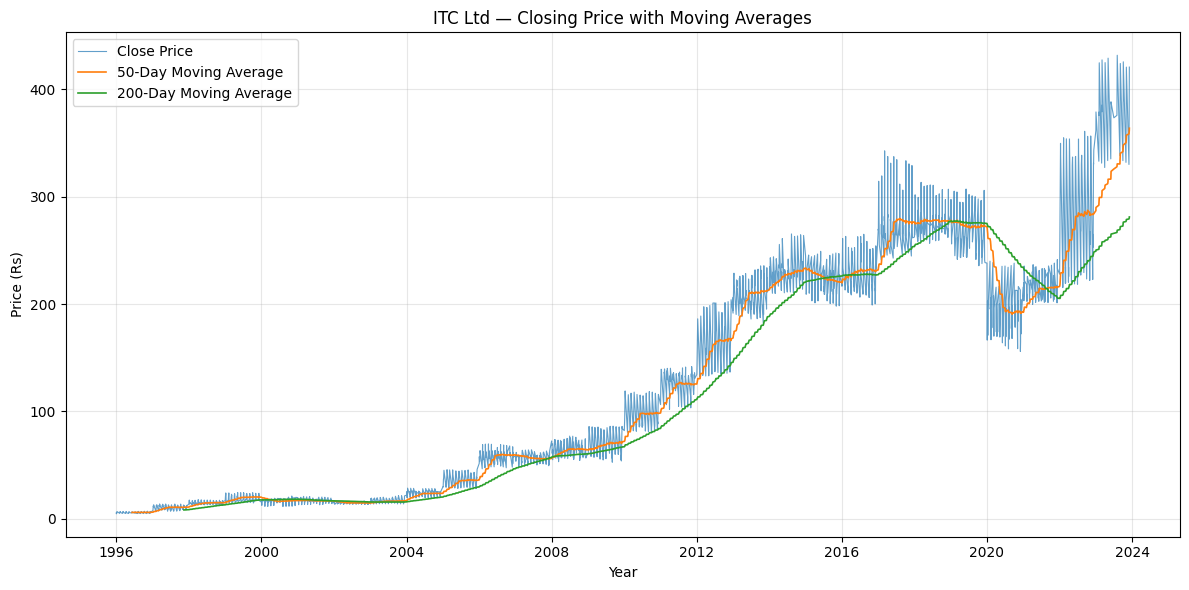

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df['Close'], label='Close Price', linewidth=0.8, alpha=0.7)
ax.plot(df.index, df['MA_50'], label='50-Day Moving Average', linewidth=1.2)
ax.plot(df.index, df['MA_200'], label='200-Day Moving Average', linewidth=1.2)

ax.set_title('ITC Ltd — Closing Price with Moving Averages')
ax.set_xlabel('Year')
ax.set_ylabel('Price (Rs)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_price_trend.png', dpi=150)
plt.show()

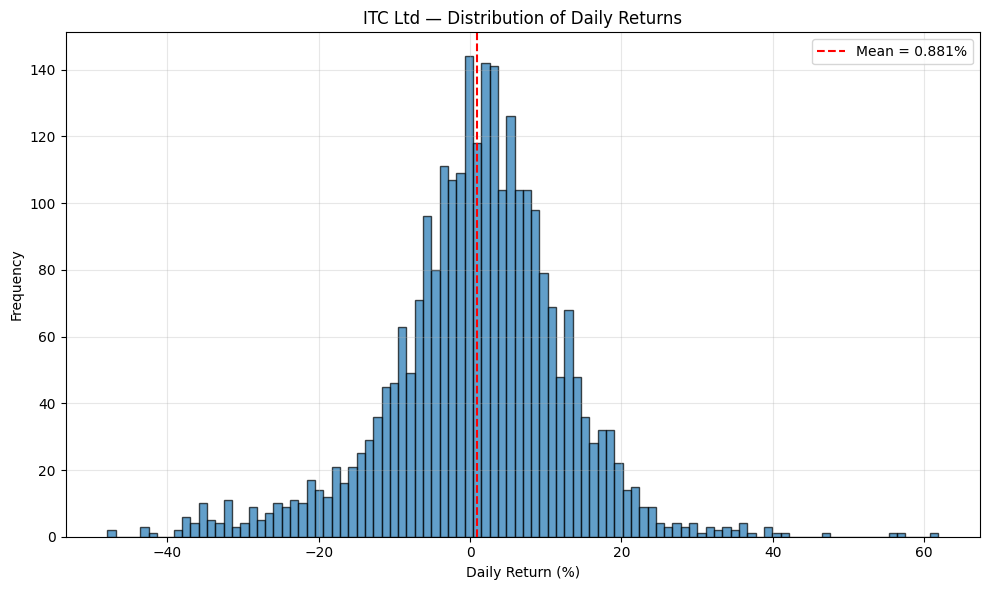

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['Daily_Return'].dropna(), bins=100, edgecolor='black', alpha=0.7)

mean_return = df['Daily_Return'].mean()
ax.axvline(mean_return, color='red', linestyle='--', label=f'Mean = {mean_return:.3f}%')

ax.set_title('ITC Ltd — Distribution of Daily Returns')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_returns_distribution.png', dpi=150)
plt.show()

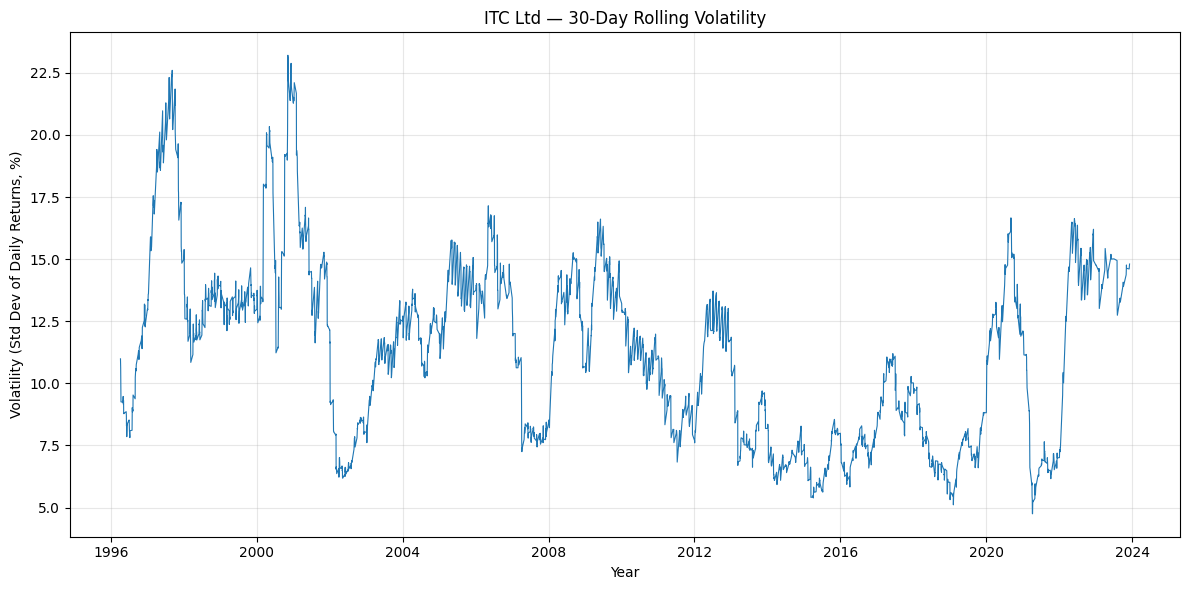


Charts saved successfully:
1. chart1_price_trend.png
2. chart2_returns_distribution.png
3. chart3_rolling_volatility.png


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df['Rolling_Volatility_30'], linewidth=0.8)

ax.set_title('ITC Ltd — 30-Day Rolling Volatility')
ax.set_xlabel('Year')
ax.set_ylabel('Volatility (Std Dev of Daily Returns, %)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart3_rolling_volatility.png', dpi=150)
plt.show()

print("\nCharts saved successfully:")
print("1. chart1_price_trend.png")
print("2. chart2_returns_distribution.png")
print("3. chart3_rolling_volatility.png")